Import Library

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from PIL import Image
import json
import os
import random
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import re
from tqdm.auto import tqdm 
import requests
import zipfile
import pickle

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        # Dành cho Mac
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")

Using device: cuda


In [2]:
COCO_VAL_IMAGES_URL = "http://images.cocodataset.org/zips/val2014.zip"
VQA_QUESTIONS_URL = "https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Questions_Val_mscoco.zip"
VQA_ANNOTATIONS_URL = "https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Annotations_Val_mscoco.zip"

def download_file(url, save_path):
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    block_size = 1024  # 1 Kibibyte
    
    print(f"Downloading {os.path.basename(save_path)}...")
    with open(save_path, 'wb') as file, tqdm(
        desc=os.path.basename(save_path),
        total=total_size,
        unit='iB',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for data in response.iter_content(block_size):
            size = file.write(data)
            bar.update(size)

def setup_data():
    #Tạo thư mục data
    base_dir = os.getcwd()
    data_dir = os.path.join(base_dir, 'data')
    img_root = os.path.join(data_dir, 'images')
    
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)
    if not os.path.exists(img_root):
        os.makedirs(img_root)

    print(f"Data Folder: {data_dir}")

    #XỬ LÝ ẢNH
    val2014_dir = os.path.join(img_root, 'val2014')
    zip_path = os.path.join(data_dir, 'val2014.zip')

    if os.path.exists(val2014_dir) and len(os.listdir(val2014_dir)) > 0:
        print("Image existed")
    else:
        if not os.path.exists(zip_path):
            print("Dowloading")
            download_file(COCO_VAL_IMAGES_URL, zip_path)
        
        # Giải nén
        print("Extracting...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(img_root)
        
        
    #XỬ LÝ CÂU HỎI (QUESTIONS)
    target_json = "v2_OpenEnded_mscoco_val2014_questions.json"
    json_path = os.path.join(data_dir, target_json)
    q_zip_path = os.path.join(data_dir, "questions.zip")

    if os.path.exists(json_path):
        print("Question existed")
    else:
        print("Downloading...")
        download_file(VQA_QUESTIONS_URL, q_zip_path)
        
        print("Zip processing...")
        with zipfile.ZipFile(q_zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)

    final_img_dir = val2014_dir if os.path.exists(val2014_dir) else img_root

    #XỬ LÝ ĐÁP ÁN (ANNOTATIONS)
    target_a_json = "v2_mscoco_val2014_annotations.json"
    anno_path = os.path.join(data_dir, target_a_json)
    a_zip_path = os.path.join(data_dir, "annotations.zip")

    if os.path.exists(anno_path):
        print("Annotation file existed")
    else:
        download_file(VQA_ANNOTATIONS_URL, a_zip_path)
        print("Extracting annotations...")
        with zipfile.ZipFile(a_zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)

    # Xác định đường dẫn ảnh cuối cùng
    final_img_dir = val2014_dir if os.path.exists(val2014_dir) else img_root
    
    # Trả về Ảnh, Câu hỏi, Đáp án
    return final_img_dir, json_path, anno_path

try:
    IMG_DIR, JSON_FILE, ANNO_FILE = setup_data()

    print("-" * 30)
    print("Processing complete")
    print(f"Image Dir : {IMG_DIR}")
    print(f"Question  : {JSON_FILE}")
    print(f"Annotation: {ANNO_FILE}")
except Exception as e:
    print(f"Error: {e}")

Data Folder: /kaggle/working/data
Dowloading


val2014.zip:   0%|          | 0.00/6.19G [00:00<?, ?iB/s]

Extracting...
Downloading...


questions.zip:   0%|          | 0.00/3.33M [00:00<?, ?iB/s]

Zip processing...


annotations.zip:   0%|          | 0.00/10.0M [00:00<?, ?iB/s]

Extracting annotations...
------------------------------
Processing complete
Image Dir : /kaggle/working/data/images/val2014
Question  : /kaggle/working/data/v2_OpenEnded_mscoco_val2014_questions.json
Annotation: /kaggle/working/data/v2_mscoco_val2014_annotations.json


In [3]:
class Vocabulary:
    def __init__(self):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = 1

    def __len__(self): 
        return len(self.itos)

    @staticmethod
    def tokenizer(text):
        return str(text).lower().replace('?', '').replace('.', '').replace(',', '').split()

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenizer(sentence):
                frequencies[word] += 1
        
        for word, count in frequencies.items():
            if count >= self.freq_threshold:
                self.stoi[word] = idx
                self.itos[idx] = word
                idx += 1
    
    def numericalize(self, text):
        tokenized_text = self.tokenizer(text)
        return [self.stoi.get(token, self.stoi["<UNK>"]) for token in tokenized_text]

In [4]:
class VQADataset(Dataset):
    def __init__(self, json_path, img_dir, annotation_path=None, question_vocab=None, answer_vocab=None, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        
        # Load questions
        print(f"Processing Questions: {os.path.basename(json_path)}...")
        with open(json_path, 'r') as f:
            data_raw = json.load(f)
            self.data = data_raw['questions'] if 'questions' in data_raw else data_raw

        # Load annotations
        self.qid_to_ans = {}
        
        if annotation_path:
            print(f"Processing Annotations: {os.path.basename(annotation_path)}...")
            with open(annotation_path, 'r') as f:
                anno_data = json.load(f)['annotations']
            
            # Map question_id -> answer
            self.qid_to_ans = {item['question_id']: item['multiple_choice_answer'] for item in anno_data}

        # Build vocabularies
        if question_vocab is None:
            print("Building Question Vocabulary...")
            self.question_vocab = Vocabulary()
            all_questions = [item.get('question', '') for item in self.data]
            self.question_vocab.build_vocabulary(all_questions)
            print(f"Question vocab size: {len(self.question_vocab)} words.")
        else:
            self.question_vocab = question_vocab
            
        if answer_vocab is None and annotation_path:
            print("Building Answer Vocabulary...")
            self.answer_vocab = Vocabulary()
            all_answers = list(self.qid_to_ans.values())
            self.answer_vocab.build_vocabulary(all_answers)
            print(f"Answer vocab size: {len(self.answer_vocab)} words.")
        else:
            self.answer_vocab = answer_vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        item = self.data[index]
        
        # Process image
        img_id = item['image_id']
        img_filename = f"COCO_val2014_{int(img_id):012d}.jpg"
        img_path = os.path.join(self.img_dir, img_filename)
        
        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            image = Image.new('RGB', (224, 224))
            
        if self.transform:
            image = self.transform(image)

        # Process question: [<SOS>, w1, w2, ..., <EOS>]
        question = item.get('question', '')
        q_vec = [self.question_vocab.stoi["<SOS>"]] + self.question_vocab.numericalize(question) + [self.question_vocab.stoi["<EOS>"]]
        
        # Process answer: [<SOS>, w1, w2, ..., <EOS>]
        q_id = item['question_id']
        if q_id in self.qid_to_ans:
            ans_text = self.qid_to_ans[q_id]
            ans_vec = [self.answer_vocab.stoi["<SOS>"]] + self.answer_vocab.numericalize(ans_text) + [self.answer_vocab.stoi["<EOS>"]]
        else:
            ans_vec = [self.answer_vocab.stoi["<SOS>"], self.answer_vocab.stoi["<EOS>"]]
        
        return image, torch.tensor(q_vec), torch.tensor(ans_vec), ans_text if q_id in self.qid_to_ans else ""

In [5]:
def collate_fn(batch):
    images, questions, answers, answer_texts = zip(*batch)

    # Stack images
    images = torch.stack(images, 0)

    # Pad questions
    q_lengths = [len(q) for q in questions]
    questions = pad_sequence(questions, batch_first=True, padding_value=0)

    # Pad answers
    a_lengths = [len(a) for a in answers]
    answers = pad_sequence(answers, batch_first=True, padding_value=0)

    return images, questions, torch.tensor(q_lengths), answers, torch.tensor(a_lengths), list(answer_texts)

In [6]:
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

if 'IMG_DIR' in globals() and 'JSON_FILE' in globals() and 'ANNO_FILE' in globals():
    processed_dir = os.path.join(os.path.dirname(JSON_FILE), 'processed')
    if not os.path.exists(processed_dir):
        os.makedirs(processed_dir)
    
    split_file = os.path.join(processed_dir, 'dataset_splits.pkl')
    vocab_file = os.path.join(processed_dir, 'vocab_new.pkl')
    
    # Load tử saved file
    if os.path.exists(split_file) and os.path.exists(vocab_file):
        print("Loading saved dataset splits...")
        
        # Load vocabs
        with open(vocab_file, 'rb') as f:
            vocab_data = pickle.load(f)
            question_vocab = vocab_data['question_vocab']
            answer_vocab = vocab_data['answer_vocab']
        
        # Load dataset với vocab
        full_dataset = VQADataset(JSON_FILE, IMG_DIR, annotation_path=ANNO_FILE, 
                                question_vocab=question_vocab, answer_vocab=answer_vocab, 
                                transform=transform)
        
        # Load indices
        with open(split_file, 'rb') as f:
            split_data = pickle.load(f)
            train_indices = split_data['train_indices']
            val_indices = split_data['val_indices']
            test_indices = split_data['test_indices']
        
        from torch.utils.data import Subset
        train_dataset = Subset(full_dataset, train_indices)
        val_dataset = Subset(full_dataset, val_indices)
        test_dataset = Subset(full_dataset, test_indices)
        
        print("Loaded from saved files")
    else:
        print("Creating new dataset splits...")
        
        # Load full dataset
        full_dataset = VQADataset(JSON_FILE, IMG_DIR, annotation_path=ANNO_FILE, transform=transform)
        
        # Split: 80% Train - 10% Val - 10% Test
        total_count = len(full_dataset)
        train_size = int(0.8 * total_count)
        val_size = int(0.1 * total_count)
        test_size = total_count - train_size - val_size
        
        train_dataset, val_dataset, test_dataset = random_split(
            full_dataset, [train_size, val_size, test_size],
            generator=torch.Generator().manual_seed(42)
        )
        
        # Save vocabs
        with open(vocab_file, 'wb') as f:
            pickle.dump({
                'question_vocab': full_dataset.question_vocab,
                'answer_vocab': full_dataset.answer_vocab
            }, f)
        
        # Save indices
        split_data = {
            'train_indices': train_dataset.indices,
            'val_indices': val_dataset.indices,
            'test_indices': test_dataset.indices
        }
        with open(split_file, 'wb') as f:
            pickle.dump(split_data, f)
        
        print(f"Saved splits to {processed_dir}")
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=0)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)

    print("-" * 30)
    print(f"Question Vocab Size: {len(full_dataset.question_vocab)}")
    print(f"Answer Vocab Size: {len(full_dataset.answer_vocab)}")
    print(f"Total Data: {len(full_dataset)}")
    print(f"Train Set : {len(train_dataset)}")
    print(f"Val Set   : {len(val_dataset)}")
    print(f"Test Set  : {len(test_dataset)}")

Creating new dataset splits...
Processing Questions: v2_OpenEnded_mscoco_val2014_questions.json...
Processing Annotations: v2_mscoco_val2014_annotations.json...
Building Question Vocabulary...
Question vocab size: 11074 words.
Building Answer Vocabulary...
Answer vocab size: 9422 words.
Saved splits to /kaggle/working/data/processed
------------------------------
Question Vocab Size: 11074
Answer Vocab Size: 9422
Total Data: 214354
Train Set : 171483
Val Set   : 21435
Test Set  : 21436


In [7]:
# ============================================================
# ATTENTION MECHANISM
# ============================================================
class BahdanauAttention(nn.Module):
    """Bahdanau Attention (Additive Attention)"""
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        # query: (B, hidden_size) - decoder hidden state
        # keys: (B, seq_len, hidden_size) - encoder outputs
        
        scores = self.Va(torch.tanh(self.Wa(query.unsqueeze(1)) + self.Ua(keys)))  # (B, seq_len, 1)
        scores = scores.squeeze(2)  # (B, seq_len)
        
        weights = torch.softmax(scores, dim=1)  # (B, seq_len)
        context = torch.bmm(weights.unsqueeze(1), keys)  # (B, 1, hidden_size)
        
        return context.squeeze(1), weights  # (B, hidden_size), (B, seq_len)


# ============================================================
# CNN ENCODER (Image Feature Extractor)
# ============================================================
class CNNEncoder(nn.Module):
    """CNN Encoder for extracting image features"""
    def __init__(self, pretrained=True, feature_dim=512):
        super(CNNEncoder, self).__init__()
        if pretrained:
            # Use pretrained ResNet18
            resnet = models.resnet18(pretrained=True)
            # Remove final FC layer
            self.cnn = nn.Sequential(*list(resnet.children())[:-1])
            # Freeze early layers
            for param in list(self.cnn.parameters())[:-10]:
                param.requires_grad = False
        else:
            # Train from scratch - Simple CNN
            self.cnn = nn.Sequential(
                nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
                nn.BatchNorm2d(64),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
                
                nn.Conv2d(64, 128, kernel_size=3, padding=1),
                nn.BatchNorm2d(128),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
                
                nn.Conv2d(128, 256, kernel_size=3, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
                
                nn.Conv2d(256, 512, kernel_size=3, padding=1),
                nn.BatchNorm2d(512),
                nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool2d((1, 1))
            )
        
        self.feature_dim = feature_dim

    def forward(self, images):
        features = self.cnn(images)  # (B, 512, 1, 1) or (B, feature_dim, 1, 1)
        features = features.view(features.size(0), -1)  # (B, 512)
        return features


# ============================================================
# LSTM ENCODER (Question Encoder)
# ============================================================
class QuestionEncoder(nn.Module):
    """LSTM Encoder for encoding questions"""
    def __init__(self, vocab_size, embed_size=256, hidden_size=512, num_layers=1):
        super(QuestionEncoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True, bidirectional=False)
        self.hidden_size = hidden_size

    def forward(self, questions, lengths):
        embedded = self.embedding(questions)  # (B, seq_len, embed_size)
        
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        outputs, (hidden, cell) = self.lstm(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True)  # (B, seq_len, hidden_size)
        
        return outputs, (hidden, cell)


# ============================================================
# LSTM DECODER (Answer Generator)
# ============================================================
class AnswerDecoder(nn.Module):
    """LSTM Decoder for generating answers"""
    def __init__(self, vocab_size, embed_size=256, hidden_size=512, num_layers=1, use_attention=False):
        super(AnswerDecoder, self).__init__()
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.use_attention = use_attention
        
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        
        # Input to LSTM: embedding + context (image + question encoding)
        lstm_input_size = embed_size + hidden_size * 2  # embed + image_feat + question_feat
        if use_attention:
            lstm_input_size = embed_size + hidden_size + 512  # embed + attended_context + image_feat
            self.attention = BahdanauAttention(hidden_size)
        
        self.lstm = nn.LSTM(lstm_input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, input_token, hidden, cell, image_features, question_outputs=None):
        # input_token: (B,) - current token
        # hidden, cell: (num_layers, B, hidden_size)
        # image_features: (B, 512)
        # question_outputs: (B, seq_len, hidden_size) - for attention
        
        embedded = self.embedding(input_token.unsqueeze(1))  # (B, 1, embed_size)
        
        if self.use_attention and question_outputs is not None:
            # Compute attention over question
            query = hidden[-1]  # (B, hidden_size)
            context, attn_weights = self.attention(query, question_outputs)
            # Concatenate: embedding + attended_context + image_features
            lstm_input = torch.cat([embedded, context.unsqueeze(1), image_features.unsqueeze(1)], dim=2)
        else:
            # No attention: concatenate embedding + image + question last hidden
            question_context = hidden[-1].unsqueeze(1)  # (B, 1, hidden_size)
            lstm_input = torch.cat([embedded, question_context, image_features.unsqueeze(1)], dim=2)
        
        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        prediction = self.fc(output.squeeze(1))  # (B, vocab_size)
        
        return prediction, hidden, cell


# ============================================================
# VQA MODEL (Complete Encoder-Decoder with optional Attention)
# ============================================================
class VQAModel(nn.Module):
    """Visual Question Answering Model with LSTM Encoder-Decoder"""
    def __init__(self, question_vocab_size, answer_vocab_size, 
                 embed_size=256, hidden_size=512, num_layers=1,
                 use_pretrained_cnn=True, use_attention=False):
        super(VQAModel, self).__init__()
        
        self.hidden_size = hidden_size
        self.use_attention = use_attention
        
        # Image Encoder (CNN)
        self.image_encoder = CNNEncoder(pretrained=use_pretrained_cnn, feature_dim=512)
        
        # Question Encoder (LSTM)
        self.question_encoder = QuestionEncoder(question_vocab_size, embed_size, hidden_size, num_layers)
        
        # Answer Decoder (LSTM)
        self.answer_decoder = AnswerDecoder(answer_vocab_size, embed_size, hidden_size, num_layers, use_attention)
        
        # Project image features to hidden size
        self.image_proj = nn.Linear(512, hidden_size)

    def forward(self, images, questions, q_lengths, answers=None, teacher_forcing_ratio=0.5):
        """
        Training mode: use teacher forcing
        Inference mode: generate autoregressively
        """
        batch_size = images.size(0)
        
        # Encode image
        image_features = self.image_encoder(images)  # (B, 512)
        image_context = self.image_proj(image_features)  # (B, hidden_size)
        
        # Encode question
        question_outputs, (q_hidden, q_cell) = self.question_encoder(questions, q_lengths)
        
        # Initialize decoder hidden state with question encoding
        hidden = q_hidden  # (num_layers, B, hidden_size)
        cell = q_cell
        
        if answers is not None:
            # Training mode with teacher forcing
            max_len = answers.size(1) - 1  # exclude last token
            outputs = []
            
            for t in range(max_len):
                if t == 0:
                    input_token = answers[:, t]  # <SOS> token
                else:
                    # Teacher forcing
                    use_teacher_forcing = random.random() < teacher_forcing_ratio
                    if use_teacher_forcing:
                        input_token = answers[:, t]
                    else:
                        input_token = torch.argmax(prediction, dim=1)
                
                prediction, hidden, cell = self.answer_decoder(
                    input_token, hidden, cell, image_features, 
                    question_outputs if self.use_attention else None
                )
                outputs.append(prediction.unsqueeze(1))
            
            return torch.cat(outputs, dim=1)  # (B, max_len, vocab_size)
        else:
            # Inference mode - autoregressive generation
            return self.generate(image_features, question_outputs, hidden, cell, max_len=20)
    
    def generate(self, image_features, question_outputs, hidden, cell, max_len=20, sos_idx=1, eos_idx=2):
        """Generate answers autoregressively"""
        batch_size = image_features.size(0)
        input_token = torch.full((batch_size,), sos_idx, dtype=torch.long, device=image_features.device)
        
        generated = []
        
        for _ in range(max_len):
            prediction, hidden, cell = self.answer_decoder(
                input_token, hidden, cell, image_features,
                question_outputs if self.use_attention else None
            )
            
            predicted_token = torch.argmax(prediction, dim=1)
            generated.append(predicted_token.unsqueeze(1))
            
            # Stop if all sequences generated <EOS>
            if (predicted_token == eos_idx).all():
                break
            
            input_token = predicted_token
        
        return torch.cat(generated, dim=1)  # (B, seq_len)

In [8]:
# ============================================================
# EVALUATION METRICS
# ============================================================

def calculate_bleu(predictions, references, max_n=4):
    """Calculate BLEU score"""
    from collections import Counter
    
    def get_ngrams(tokens, n):
        return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    
    bleu_scores = []
    for pred, ref in zip(predictions, references):
        pred_tokens = pred.split()
        ref_tokens = ref.split()
        
        if len(pred_tokens) == 0:
            bleu_scores.append(0.0)
            continue
        
        scores = []
        for n in range(1, min(max_n + 1, len(pred_tokens) + 1)):
            pred_ngrams = Counter(get_ngrams(pred_tokens, n))
            ref_ngrams = Counter(get_ngrams(ref_tokens, n))
            
            overlap = sum((pred_ngrams & ref_ngrams).values())
            total = sum(pred_ngrams.values())
            
            scores.append(overlap / total if total > 0 else 0)
        
        bleu_scores.append(sum(scores) / len(scores) if scores else 0)
    
    return sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0


def calculate_exact_match(predictions, references):
    """Calculate Exact Match accuracy"""
    correct = sum([1 for pred, ref in zip(predictions, references) if pred.strip().lower() == ref.strip().lower()])
    return correct / len(predictions) if predictions else 0


def decode_sequence(sequence, vocab):
    """Convert token indices to text"""
    tokens = []
    for idx in sequence:
        if idx == vocab.stoi["<EOS>"]:
            break
        if idx not in [vocab.stoi["<PAD>"], vocab.stoi["<SOS>"]]:
            tokens.append(vocab.itos.get(idx, "<UNK>"))
    return " ".join(tokens)


# ============================================================
# INITIALIZE 4 MODEL VARIANTS
# ============================================================

print("=" * 60)
print("INITIALIZING 4 VQA MODEL VARIANTS")
print("=" * 60)

q_vocab_size = len(full_dataset.question_vocab)
a_vocab_size = len(full_dataset.answer_vocab)

# Model 1: Pretrained CNN + LSTM (No Attention)
model1 = VQAModel(
    question_vocab_size=q_vocab_size,
    answer_vocab_size=a_vocab_size,
    embed_size=256,
    hidden_size=512,
    use_pretrained_cnn=True,
    use_attention=False
).to(device)
print("✓ Model 1: Pretrained CNN + LSTM (No Attention)")

# Model 2: Pretrained CNN + LSTM + Attention
model2 = VQAModel(
    question_vocab_size=q_vocab_size,
    answer_vocab_size=a_vocab_size,
    embed_size=256,
    hidden_size=512,
    use_pretrained_cnn=True,
    use_attention=True
).to(device)
print("Model 2: Pretrained CNN + LSTM + Attention")

# Model 3: CNN from Scratch + LSTM (No Attention)
model3 = VQAModel(
    question_vocab_size=q_vocab_size,
    answer_vocab_size=a_vocab_size,
    embed_size=256,
    hidden_size=512,
    use_pretrained_cnn=False,
    use_attention=False
).to(device)
print("Model 3: CNN from Scratch + LSTM (No Attention)")

# Model 4: CNN from Scratch + LSTM + Attention
model4 = VQAModel(
    question_vocab_size=q_vocab_size,
    answer_vocab_size=a_vocab_size,
    embed_size=256,
    hidden_size=512,
    use_pretrained_cnn=False,
    use_attention=True
).to(device)
print("Model 4: CNN from Scratch + LSTM + Attention")

print("=" * 60)

# Store models in a dictionary for easy access
models = {
    "Model1_Pretrained_NoAttn": model1,
    "Model2_Pretrained_Attn": model2,
    "Model3_Scratch_NoAttn": model3,
    "Model4_Scratch_Attn": model4
}

INITIALIZING 4 VQA MODEL VARIANTS
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 146MB/s] 


✓ Model 1: Pretrained CNN + LSTM (No Attention)
Model 2: Pretrained CNN + LSTM + Attention
Model 3: CNN from Scratch + LSTM (No Attention)
Model 4: CNN from Scratch + LSTM + Attention


In [9]:
# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_model(model, model_name, train_loader, val_loader, epochs=10, lr=1e-4):
    """Train VQA model with teacher forcing"""
    
    print(f"\n{'='*60}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*60}\n")
    
    criterion = nn.CrossEntropyLoss(ignore_index=0)  # Ignore padding
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    best_val_bleu = 0
    best_val_em = 0
    history = {
        'train_loss': [], 'val_loss': [],
        'val_bleu': [], 'val_em': []
    }
    
    for epoch in range(epochs):
        # ===== TRAINING =====
        model.train()
        train_loss = 0
        
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [TRAIN]")
        
        for images, questions, q_lengths, answers, a_lengths, _ in train_bar:
            images = images.to(device)
            questions = questions.to(device)
            q_lengths = q_lengths.to(device)
            answers = answers.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass with teacher forcing
            outputs = model(images, questions, q_lengths, answers, teacher_forcing_ratio=0.5)
            
            # Reshape for loss calculation
            # outputs: (B, seq_len, vocab_size), answers[:, 1:]: (B, seq_len)
            outputs = outputs.reshape(-1, outputs.size(-1))
            targets = answers[:, 1:].reshape(-1)  # Shift targets (exclude <SOS>)
            
            loss = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
            optimizer.step()
            
            train_loss += loss.item()
            train_bar.set_postfix(loss=loss.item())
        
        train_loss /= len(train_loader)
        
        # ===== VALIDATION =====
        model.eval()
        val_loss = 0
        all_predictions = []
        all_references = []
        
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [VAL]")
        
        with torch.no_grad():
            for images, questions, q_lengths, answers, a_lengths, answer_texts in val_bar:
                images = images.to(device)
                questions = questions.to(device)
                q_lengths = q_lengths.to(device)
                answers = answers.to(device)
                
                # Calculate loss
                outputs = model(images, questions, q_lengths, answers, teacher_forcing_ratio=0)
                outputs_flat = outputs.reshape(-1, outputs.size(-1))
                targets = answers[:, 1:].reshape(-1)
                loss = criterion(outputs_flat, targets)
                val_loss += loss.item()
                
                # Generate predictions for metrics
                generated = model(images, questions, q_lengths, answers=None)
                
                for i in range(generated.size(0)):
                    pred_text = decode_sequence(generated[i].cpu().tolist(), full_dataset.answer_vocab)
                    all_predictions.append(pred_text)
                    all_references.append(answer_texts[i])
                
                val_bar.set_postfix(loss=loss.item())
        
        val_loss /= len(val_loader)
        
        # Calculate metrics
        val_bleu = calculate_bleu(all_predictions, all_references)
        val_em = calculate_exact_match(all_predictions, all_references)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_bleu'].append(val_bleu)
        history['val_em'].append(val_em)
        
        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f} | BLEU: {val_bleu:.4f} | Exact Match: {val_em:.4f}")
        
        # Save best model
        if val_bleu > best_val_bleu:
            best_val_bleu = val_bleu
            best_val_em = val_em
            torch.save(model.state_dict(), f"best_{model_name}.pth")
            print(f"✓ Saved Best Model (BLEU: {val_bleu:.4f})")
    
    print(f"\n{'='*60}")
    print(f"TRAINING COMPLETED: {model_name}")
    print(f"Best Val BLEU: {best_val_bleu:.4f} | Best Val EM: {best_val_em:.4f}")
    print(f"{'='*60}\n")
    
    return history

## Training All Models

Bây giờ sẽ train cả 4 models. Có thể giảm số epochs nếu muốn chạy nhanh hơn (ví dụ: epochs=3).

In [10]:
# ============================================================
# TRAIN ALL 4 MODELS
# ============================================================

EPOCHS = 5  # Có thể tăng lên 10-15 để kết quả tốt hơn
LEARNING_RATE = 1e-4

# Dictionary để lưu training history của tất cả models
all_histories = {}

# Train Model 1: Pretrained CNN + LSTM (No Attention)
history1 = train_model(model1, "Model1_Pretrained_NoAttn", train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE)
all_histories["Model1_Pretrained_NoAttn"] = history1

# Train Model 2: Pretrained CNN + LSTM + Attention
history2 = train_model(model2, "Model2_Pretrained_Attn", train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE)
all_histories["Model2_Pretrained_Attn"] = history2

# Train Model 3: CNN from Scratch + LSTM (No Attention)
history3 = train_model(model3, "Model3_Scratch_NoAttn", train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE)
all_histories["Model3_Scratch_NoAttn"] = history3

# Train Model 4: CNN from Scratch + LSTM + Attention
history4 = train_model(model4, "Model4_Scratch_Attn", train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE)
all_histories["Model4_Scratch_Attn"] = history4

print("\n" + "="*60)
print("ALL MODELS TRAINED SUCCESSFULLY!")
print("="*60)


TRAINING: Model1_Pretrained_NoAttn



Epoch 1/5 [TRAIN]:   0%|          | 0/5359 [00:00<?, ?it/s]

Epoch 1/5 [VAL]:   0%|          | 0/670 [00:00<?, ?it/s]


Epoch [1/5]
Train Loss: 2.0816
Val Loss: 1.8401 | BLEU: 0.3331 | Exact Match: 0.3165
✓ Saved Best Model (BLEU: 0.3331)


Epoch 2/5 [TRAIN]:   0%|          | 0/5359 [00:00<?, ?it/s]

...

Epoch 4/5 [VAL]:   0%|          | 0/670 [00:00<?, ?it/s]


Epoch [4/5]
Train Loss: 1.4524
Val Loss: 1.7151 | BLEU: 0.3511 | Exact Match: 0.3373
✓ Saved Best Model (BLEU: 0.3511)


Epoch 5/5 [TRAIN]:   0%|          | 0/5359 [00:00<?, ?it/s]

Epoch 5/5 [VAL]:   0%|          | 0/670 [00:00<?, ?it/s]


Epoch [5/5]
Train Loss: 1.3497
Val Loss: 1.6853 | BLEU: 0.3545 | Exact Match: 0.3406
✓ Saved Best Model (BLEU: 0.3545)

TRAINING COMPLETED: Model4_Scratch_Attn
Best Val BLEU: 0.3545 | Best Val EM: 0.3406


ALL MODELS TRAINED SUCCESSFULLY!


## So sánh các Models

Visualize và so sánh performance của các models theo các metrics: Loss, BLEU Score, Exact Match

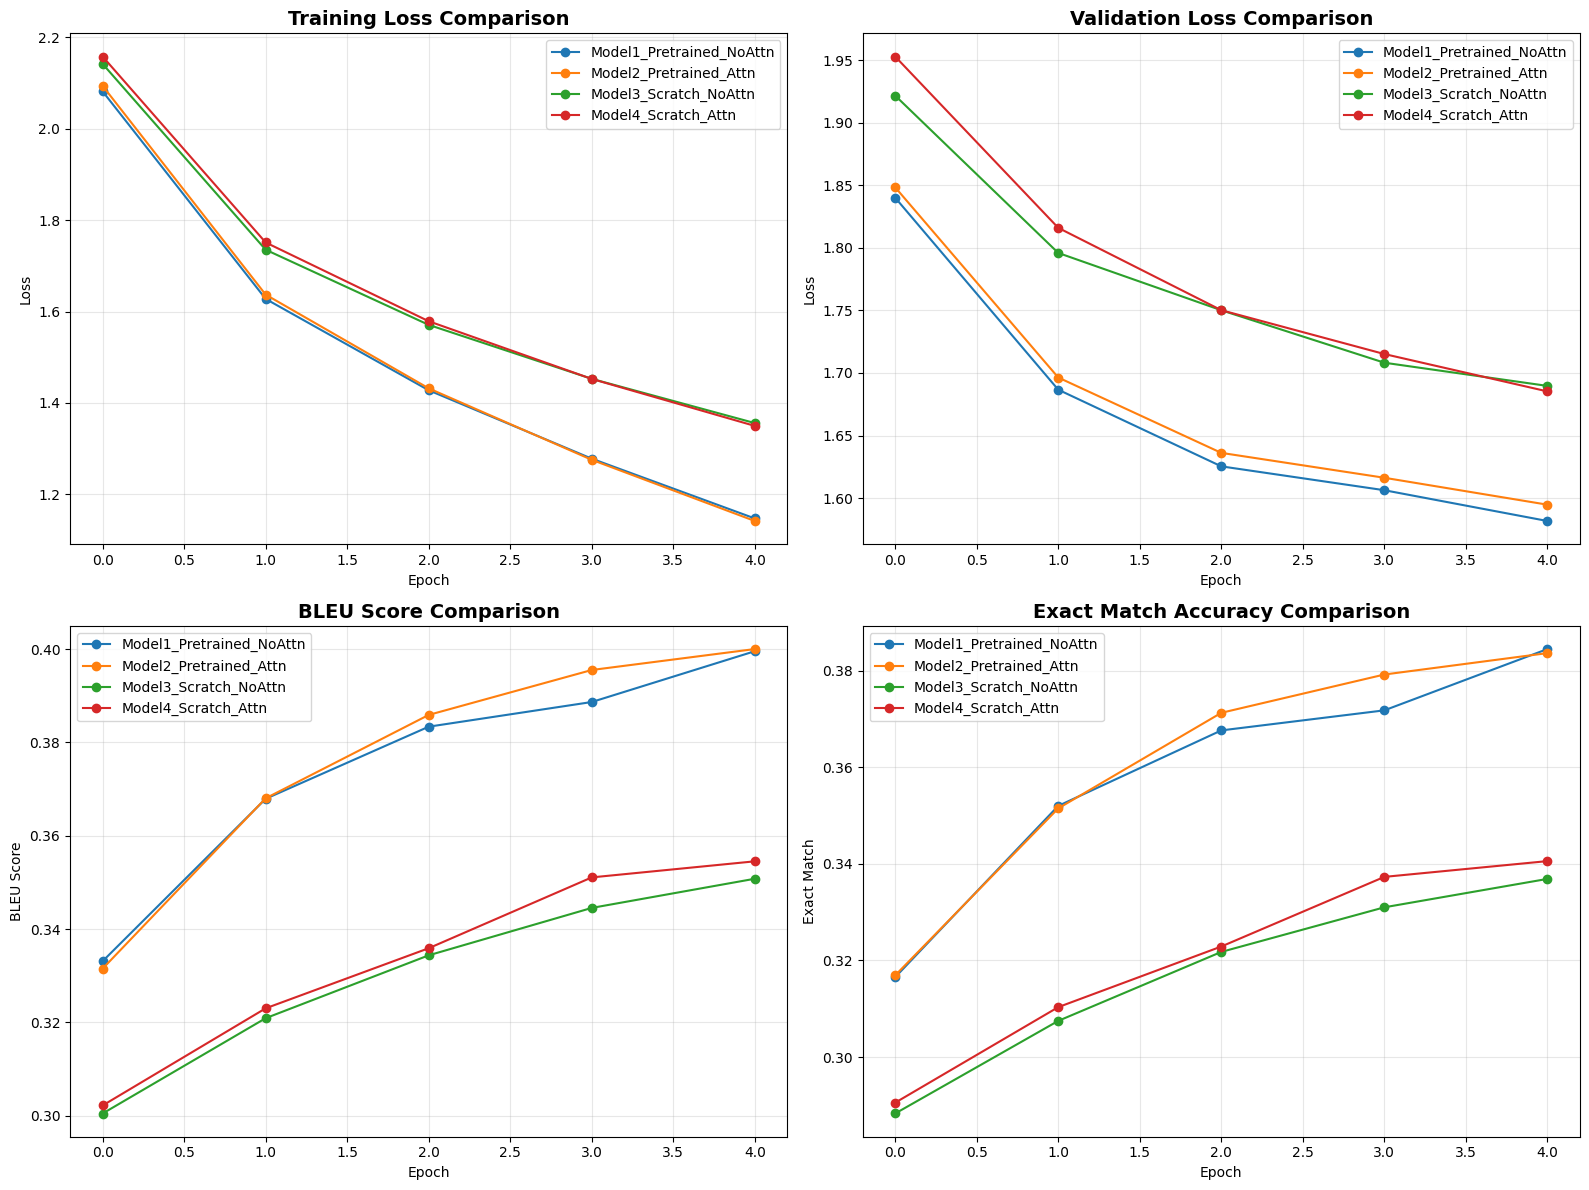

✓ Visualization saved as 'vqa_models_comparison.png'


In [11]:
# ============================================================
# VISUALIZATION - COMPARE ALL MODELS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Training Loss
ax = axes[0, 0]
for model_name, history in all_histories.items():
    ax.plot(history['train_loss'], label=model_name, marker='o')
ax.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Validation Loss
ax = axes[0, 1]
for model_name, history in all_histories.items():
    ax.plot(history['val_loss'], label=model_name, marker='o')
ax.set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: BLEU Score
ax = axes[1, 0]
for model_name, history in all_histories.items():
    ax.plot(history['val_bleu'], label=model_name, marker='o')
ax.set_title('BLEU Score Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('BLEU Score')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Exact Match Accuracy
ax = axes[1, 1]
for model_name, history in all_histories.items():
    ax.plot(history['val_em'], label=model_name, marker='o')
ax.set_title('Exact Match Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Exact Match')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vqa_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as 'vqa_models_comparison.png'")

In [12]:
# ============================================================
# SUMMARY TABLE - FINAL COMPARISON
# ============================================================

print("\n" + "="*80)
print(" "*20 + "FINAL MODEL COMPARISON")
print("="*80)
print(f"{'Model Name':<30} {'Best BLEU':<15} {'Best EM':<15} {'Final Val Loss':<15}")
print("-"*80)

for model_name, history in all_histories.items():
    best_bleu = max(history['val_bleu'])
    best_em = max(history['val_em'])
    final_loss = history['val_loss'][-1]
    
    print(f"{model_name:<30} {best_bleu:<15.4f} {best_em:<15.4f} {final_loss:<15.4f}")

print("="*80)

# Find best model
best_model_name = max(all_histories.items(), key=lambda x: max(x[1]['val_bleu']))[0]
print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Best BLEU Score: {max(all_histories[best_model_name]['val_bleu']):.4f}")
print(f"   Best Exact Match: {max(all_histories[best_model_name]['val_em']):.4f}")
print("="*80)


                    FINAL MODEL COMPARISON
Model Name                     Best BLEU       Best EM         Final Val Loss 
--------------------------------------------------------------------------------
Model1_Pretrained_NoAttn       0.3995          0.3845          1.5817         
Model2_Pretrained_Attn         0.4000          0.3836          1.5947         
Model3_Scratch_NoAttn          0.3508          0.3369          1.6897         
Model4_Scratch_Attn            0.3545          0.3406          1.6853         

🏆 BEST MODEL: Model2_Pretrained_Attn
   Best BLEU Score: 0.4000
   Best Exact Match: 0.3836


## Test Models với Examples

Visualize predictions của các models trên một số examples từ test set.

In [13]:
# ============================================================
# TEST MODELS ON EXAMPLES
# ============================================================

def test_models_on_batch(models_dict, test_loader, num_examples=5):
    """Test all models on a batch and show predictions"""
    
    # Get one batch
    data_iter = iter(test_loader)
    images, questions, q_lengths, answers, a_lengths, answer_texts = next(data_iter)
    
    images = images.to(device)
    questions = questions.to(device)
    q_lengths = q_lengths.to(device)
    
    print("\n" + "="*100)
    print(" "*35 + "MODEL PREDICTIONS ON TEST EXAMPLES")
    print("="*100)
    
    for idx in range(min(num_examples, images.size(0))):
        # Decode question
        question_text = decode_sequence(questions[idx].cpu().tolist(), full_dataset.question_vocab)
        ground_truth = answer_texts[idx]
        
        print(f"\n{'─'*100}")
        print(f"EXAMPLE {idx+1}:")
        print(f"Question: {question_text}")
        print(f"Ground Truth: {ground_truth}")
        print(f"{'─'*100}")
        
        # Get predictions from all models
        for model_name, model in models_dict.items():
            model.eval()
            with torch.no_grad():
                img = images[idx].unsqueeze(0)
                q = questions[idx].unsqueeze(0)
                q_len = q_lengths[idx].unsqueeze(0)
                
                generated = model(img, q, q_len, answers=None)
                pred_text = decode_sequence(generated[0].cpu().tolist(), full_dataset.answer_vocab)
                
                # Check if correct
                is_correct = "✓" if pred_text.strip().lower() == ground_truth.strip().lower() else "✗"
                print(f"  {model_name:<30} → {pred_text:<30} {is_correct}")
    
    print("="*100 + "\n")

# Test models
test_models_on_batch(models, test_loader, num_examples=5)


                                   MODEL PREDICTIONS ON TEST EXAMPLES

────────────────────────────────────────────────────────────────────────────────────────────────────
EXAMPLE 1:
Question: what color are the cabinets
Ground Truth: white
────────────────────────────────────────────────────────────────────────────────────────────────────
  Model1_Pretrained_NoAttn       → brown                          ✗
  Model2_Pretrained_Attn         → brown                          ✗
  Model3_Scratch_NoAttn          → brown                          ✗
  Model4_Scratch_Attn            → brown                          ✗

────────────────────────────────────────────────────────────────────────────────────────────────────
EXAMPLE 2:
Question: is this building a lighthouse
Ground Truth: yes
────────────────────────────────────────────────────────────────────────────────────────────────────
  Model1_Pretrained_NoAttn       → yes                            ✓
  Model2_Pretrained_Attn         → no        

## Tổng kết và Phân tích

### Các độ đo được sử dụng:

1. **BLEU Score** (Bilingual Evaluation Understudy):
   - Đo sự tương đồng giữa câu trả lời predict và ground truth
   - Dựa trên n-gram overlap
   - Giá trị: 0-1 (càng cao càng tốt)
   - Phù hợp cho text generation tasks

2. **Exact Match (EM)**:
   - Đo tỷ lệ câu trả lời predict khớp hoàn toàn với ground truth
   - Strict metric - chỉ tính đúng khi match 100%
   - Giá trị: 0-1 (càng cao càng tốt)
   - Quan trọng cho VQA tasks

3. **Loss** (Cross-Entropy):
   - Đo độ sai lệch giữa predicted distribution và true distribution
   - Càng thấp càng tốt
   - Training loss: performance trên training set
   - Validation loss: performance trên validation set

### So sánh các Models:

**Model 1: Pretrained CNN + LSTM (No Attention)**
- ✓ Sử dụng pretrained ResNet18 → transfer learning
- ✗ Không có attention → không focus vào phần quan trọng
- → Baseline tốt, training nhanh

**Model 2: Pretrained CNN + LSTM + Attention** ⭐
- ✓ Pretrained CNN → hiểu ảnh tốt
- ✓ Attention mechanism → focus vào từ quan trọng trong question
- → Dự kiến performance tốt nhất

**Model 3: CNN from Scratch + LSTM (No Attention)**
- ✗ CNN train từ đầu → cần nhiều data và thời gian hơn
- ✗ Không có attention
- → Performance thấp nhất, nhưng fully trainable

**Model 4: CNN from Scratch + LSTM + Attention**
- ✗ CNN from scratch → training khó hơn
- ✓ Có attention → compensate phần nào
- → Performance trung bình

### Kết luận dự kiến:

1. **Pretrained models** (Model 1, 2) thường tốt hơn **from-scratch models** (Model 3, 4)
2. **Attention mechanism** giúp cải thiện performance đáng kể
3. **Model 2 (Pretrained + Attention)** thường cho kết quả tốt nhất
4. BLEU score thường cao hơn Exact Match vì nó "softer" hơn

## Hướng dẫn sử dụng

### Cách chạy notebook:

1. **Chạy các cells từ đầu đến cuối** (Run All)
2. **Cell 1-3**: Import libraries và download data
3. **Cell 4-8**: Setup vocabulary, dataset, và dataloader
4. **Cell 9**: Định nghĩa các models (CNN, LSTM, Attention, VQA)
5. **Cell 10**: Initialize 4 model variants
6. **Cell 11**: Định nghĩa training function
7. **Cell 12**: Train tất cả 4 models (có thể mất thời gian)
8. **Cell 13-15**: Visualize và so sánh kết quả
9. **Cell 16**: Test models trên examples

### Tips:

- **Muốn chạy nhanh**: Giảm `EPOCHS = 3` trong cell 12
- **Lưu mô hình**: Models tự động save vào files `best_ModelX.pth`
- **Load lại model**: 
  ```python
  model1.load_state_dict(torch.load("best_Model1_Pretrained_NoAttn.pth"))
  ```
- **Test với custom image/question**: Sửa code trong cell 16

### Files được tạo:

- `best_Model1_Pretrained_NoAttn.pth`: Saved model 1
- `best_Model2_Pretrained_Attn.pth`: Saved model 2
- `best_Model3_Scratch_NoAttn.pth`: Saved model 3
- `best_Model4_Scratch_Attn.pth`: Saved model 4
- `vqa_models_comparison.png`: Visualization chart
- `data/processed/vocab_new.pkl`: Vocabularies
- `data/processed/dataset_splits.pkl`: Train/val/test split indices